# پروژه آموزشی: همبستگی و Cross Validation

در این نوت‌بوک، مفاهیم مهم درس شامل موارد زیر را به‌صورت عملی بررسی می‌کنیم:

- آشنایی با دیتاست
- محاسبه همبستگی بین ویژگی‌ها
- رسم ماتریس همبستگی و Heatmap
- بررسی رابطه هر ویژگی با متغیر هدف
- محاسبه دستی ضریب همبستگی پیرسون
- مهندسی ویژگی (Feature Engineering)
- آموزش مدل رگرسیون خطی
- ارزیابی مدل با K-Fold Cross Validation
- بررسی ضعیف‌ترین Fold
- مشاهده اثر داده‌های پرت (Outlier)

هدف این تمرین، فقط اجرای کد نیست؛ بلکه درک مفهومی رفتار داده‌ها و مدل نیز مهم است.


## 1) نصب و بارگذاری کتابخانه‌ها

در این بخش کتابخانه‌های موردنیاز را نصب و سپس import می‌کنیم.

کتابخانه‌های اصلی ما عبارت‌اند از:

- `pandas` برای کار با داده‌های جدولی
- `numpy` برای محاسبات عددی
- `matplotlib` و `seaborn` برای رسم نمودار
- `scikit-learn` برای مدل‌سازی و Cross Validation


In [ ]:
!pip -q install seaborn scikit-learn


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## 2) آپلود فایل CSV در Google Colab

در این مرحله فایل دیتاست را از سیستم خودت داخل Colab آپلود می‌کنی.

فایل موردنیاز:

- `correlation_cv_dataset.csv`

بعد از اجرای سلول بعدی، پنجره انتخاب فایل باز می‌شود. فایل CSV را انتخاب کن.


In [ ]:
uploaded = files.upload()


Saving correlation_cv_dataset.csv to correlation_cv_dataset.csv


## 3) خواندن دیتاست

بعد از آپلود فایل، آن را با `pandas` می‌خوانیم.

این دیتاست شامل ستون‌های زیر است:

- `rainfall` : میزان بارش
- `dam_level` : تراز سد
- `temperature` : دما
- `evaporation` : میزان تبخیر
- `water_release` : خروجی آب
- `target_storage` : متغیر هدف


In [ ]:
df = pd.read_csv("correlation_cv_dataset.csv")

print("Dataset loaded successfully.")
display(df.head())
print("Shape:", df.shape)


Dataset loaded successfully.


,rainfall,dam_level,temperature,evaporation,water_release,target_storage
0,137.384995,72.249753,29.557065,41.194843,95.567222,58.052560
1,115.160749,64.060033,35.456500,37.397069,68.976286,55.528712
2,142.669099,77.191454,15.608595,30.477043,63.636022,63.030796
3,173.306045,103.363187,27.377815,24.824506,79.932511,79.277469
4,111.804632,44.840417,20.096145,35.585787,76.596308,23.975005


Shape: (500, 6)


## 4) بررسی اولیه داده‌ها

قبل از هر تحلیل، باید شناخت اولیه‌ای از داده داشته باشیم.

در این مرحله موارد زیر را بررسی می‌کنیم:

- نام ستون‌ها
- نوع داده‌ها
- تعداد داده‌های خالی
- آمار توصیفی


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe())


Columns:
['rainfall', 'dam_level', 'temperature', 'evaporation', 'water_release', 'target_storage']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rainfall        500 non-null    float64
 1   dam_level       500 non-null    float64
 2   temperature     500 non-null    float64
 3   evaporation     500 non-null    float64
 4   water_release   500 non-null    float64
 5   target_storage  500 non-null    float64
dtypes: float64(6)
memory usage: 23.6 KB

Missing values:
rainfall          0
dam_level         0
temperature       0
evaporation       0
water_release     0
target_storage    0
dtype: int64

Descriptive statistics:


,rainfall,dam_level,temperature,evaporation,water_release,target_storage
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,122.390337,70.323432,24.190957,30.867876,80.663759,50.945981
std,38.597332,24.451031,5.867983,8.081971,19.681323,28.871210
min,6.555643,2.731746,7.818680,6.829957,21.192227,-17.603529
25%,95.688525,53.609186,20.428250,25.180563,67.761277,31.373518
50%,120.796495,70.170467,24.171190,30.958447,79.821733,49.837116
75%,143.525385,87.769596,27.907454,36.037907,93.995388,70.176502
max,284.232228,154.643402,39.794292,50.813465,143.862151,170.236558


## 5) تعریف ویژگی‌ها و متغیر هدف

در یادگیری ماشین معمولاً:

- `X` شامل ویژگی‌هاست
- `y` شامل متغیر هدف است

در اینجا ستون `target_storage` را به‌عنوان هدف در نظر می‌گیریم.


In [ ]:
target = "target_storage"

X = df.drop(columns=[target])
y = df[target]

print("Feature columns:", X.columns.tolist())
print("Target column:", target)


Feature columns: ['rainfall', 'dam_level', 'temperature', 'evaporation', 'water_release']
Target column: target_storage


## 6) محاسبه ماتریس همبستگی

همبستگی میزان رابطه خطی بین دو متغیر را نشان می‌دهد.

مقدار آن بین `1-` تا `1+` است:

- نزدیک `1+` یعنی رابطه مثبت قوی
- نزدیک `1-` یعنی رابطه منفی قوی
- نزدیک `0` یعنی رابطه خطی ضعیف

نکته مهم:
همبستگی بالا لزوماً به معنی رابطه علت و معلولی نیست.


In [ ]:
corr_matrix = df.corr(numeric_only=True)

print("Correlation Matrix:")
display(corr_matrix.round(2))


Correlation Matrix:


,rainfall,dam_level,temperature,evaporation,water_release,target_storage
rainfall,1.00,0.84,-0.09,-0.08,0.06,0.88
dam_level,0.84,1.00,-0.07,-0.15,0.03,0.82
temperature,-0.09,-0.07,1.00,0.08,-0.02,-0.08
evaporation,-0.08,-0.15,0.08,1.00,-0.02,-0.17
water_release,0.06,0.03,-0.02,-0.02,1.00,-0.08
target_storage,0.88,0.82,-0.08,-0.17,-0.08,1.00


## 7) رسم Heatmap

Heatmap نمایش بصری ماتریس همبستگی است و کمک می‌کند الگوها را سریع‌تر ببینیم.

در این نمودار:

- رنگ‌های گرم‌تر معمولاً نشان‌دهنده همبستگی مثبت‌اند
- رنگ‌های سردتر معمولاً نشان‌دهنده همبستگی منفی‌اند
- اعداد داخل هر خانه مقدار دقیق همبستگی را نشان می‌دهند


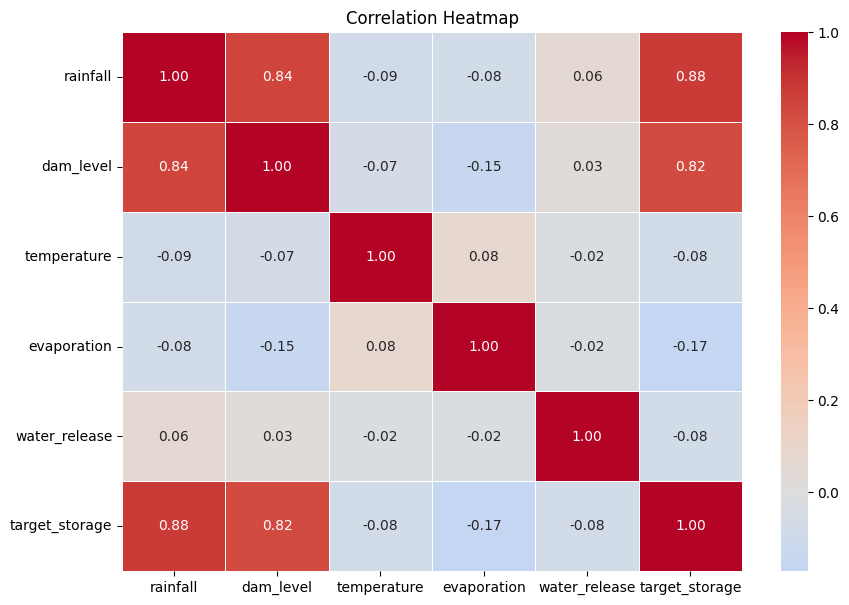

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()


## 8) بررسی همبستگی هر ویژگی با متغیر هدف

در این بخش بررسی می‌کنیم هر ویژگی چه میزان با `target_storage` رابطه دارد.

ویژگی‌ها را بر اساس قدر مطلق همبستگی مرتب می‌کنیم تا مهم‌ترین آن‌ها سریع‌تر مشخص شوند.


In [ ]:
target_corr = corr_matrix[target].drop(target).sort_values(key=np.abs, ascending=False)

print("Correlation of features with target_storage:")
display(target_corr.to_frame("correlation"))


Correlation of features with target_storage:


,correlation
rainfall,0.880953
dam_level,0.822750
evaporation,-0.171427
temperature,-0.084046
water_release,-0.080914


## 9) تفسیر ساده ضرایب همبستگی

در اینجا برای هر ویژگی یک تفسیر متنی ساده ارائه می‌کنیم.

این دسته‌بندی تقریبی است و فقط برای درک بهتر مفهوم استفاده می‌شود.


In [ ]:
for feature, value in target_corr.items():
    if value >= 0.7:
        strength = "strong positive"
    elif value >= 0.5:
        strength = "moderate positive"
    elif value >= 0.3:
        strength = "weak positive"
    elif value <= -0.7:
        strength = "strong negative"
    elif value <= -0.5:
        strength = "moderate negative"
    elif value <= -0.3:
        strength = "weak negative"
    else:
        strength = "little or no linear relation"

    print(f"{feature}: {value:.3f} --> {strength}")


rainfall: 0.881 --> strong positive
dam_level: 0.823 --> strong positive
evaporation: -0.171 --> little or no linear relation
temperature: -0.084 --> little or no linear relation
water_release: -0.081 --> little or no linear relation


## 10) محاسبه دستی ضریب همبستگی پیرسون

در این قسمت ضریب همبستگی پیرسون را برای ویژگی `rainfall` نسبت به متغیر هدف، به‌صورت دستی محاسبه می‌کنیم.

سپس نتیجه را با خروجی تابع آماده `pandas` مقایسه می‌کنیم تا درستی محاسبه مشخص شود.


In [ ]:
feature_name = "rainfall"

x = df[feature_name].to_numpy()
y_np = df[target].to_numpy()

x_mean = x.mean()
y_mean = y_np.mean()

numerator = np.sum((x - x_mean) * (y_np - y_mean))
denominator = np.sqrt(
    np.sum((x - x_mean) ** 2) *
    np.sum((y_np - y_mean) ** 2)
)

pearson_manual = numerator / denominator
pearson_pandas = df[feature_name].corr(df[target])

print("Feature:", feature_name)
print("Pearson correlation - manual:", pearson_manual)
print("Pearson correlation - pandas:", pearson_pandas)


Feature: rainfall
Pearson correlation - manual: 0.8809532302415953
Pearson correlation - pandas: 0.8809532302415962


## 11) رسم Scatter Plot

Scatter Plot به ما کمک می‌کند رابطه دو متغیر را به‌صورت تصویری ببینیم.

در اینجا رابطه بین `rainfall` و `target_storage` را بررسی می‌کنیم.


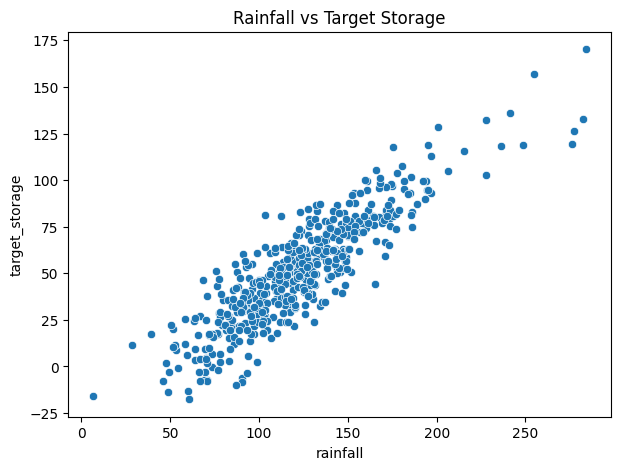

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="rainfall", y="target_storage")
plt.title("Rainfall vs Target Storage")
plt.show()


## 12) مهندسی ویژگی

گاهی ترکیب چند ویژگی می‌تواند اطلاعات بهتری به مدل بدهد.

در اینجا یک ویژگی جدید می‌سازیم:

- `rainfall_dam_interaction`

که حاصل ضرب `rainfall` در `dam_level` است.


In [ ]:
df["rainfall_dam_interaction"] = df["rainfall"] * df["dam_level"]

print("New feature created: rainfall_dam_interaction")
display(df[["rainfall", "dam_level", "rainfall_dam_interaction", "target_storage"]].head())

print("Correlation with target:")
print(df["rainfall_dam_interaction"].corr(df["target_storage"]))


New feature created: rainfall_dam_interaction


,rainfall,dam_level,rainfall_dam_interaction,target_storage
0,137.384995,72.249753,9926.032030,58.052560
1,115.160749,64.060033,7377.201419,55.528712
2,142.669099,77.191454,11012.835221,63.030796
3,173.306045,103.363187,17913.465220,79.277469
4,111.804632,44.840417,5013.366364,23.975005


Correlation with target:
0.8752829484833446


## 13) بازتعریف X و y بعد از مهندسی ویژگی

چون یک ستون جدید به دیتاست اضافه شده، باید دوباره `X` و `y` را تعریف کنیم تا مدل از ویژگی جدید هم استفاده کند.


In [ ]:
X = df.drop(columns=[target])
y = df[target]

print("Updated feature columns:")
print(X.columns.tolist())


Updated feature columns:
['rainfall', 'dam_level', 'temperature', 'evaporation', 'water_release', 'rainfall_dam_interaction']


## 14) آموزش مدل پایه رگرسیون خطی

در این مرحله یک مدل `LinearRegression` روی کل داده آموزش می‌دهیم.

دو معیار را بررسی می‌کنیم:

- `R2`
- `RMSE`

توجه:
این ارزیابی هنوز ارزیابی نهایی و واقعی نیست، چون مدل روی همان داده‌ای تست می‌شود که با آن آموزش دیده است.


In [ ]:
model = LinearRegression()
model.fit(X, y)

pred_all = model.predict(X)

r2_all = r2_score(y, pred_all)
mse_all = mean_squared_error(y, pred_all)
rmse_all = np.sqrt(mse_all)

print("Train R2 on full dataset:", r2_all)
print("Train RMSE on full dataset:", rmse_all)


Train R2 on full dataset: 0.8223540370333643
Train RMSE on full dataset: 12.156482328186813


## 15) تعریف K-Fold Cross Validation

برای ارزیابی بهتر مدل، از K-Fold استفاده می‌کنیم.

در این روش:

- داده‌ها به 5 بخش تقسیم می‌شوند
- هر بار یک بخش برای تست و 4 بخش برای آموزش استفاده می‌شوند
- در پایان میانگین عملکرد همه Foldها محاسبه می‌شود

در اینجا `shuffle=False` قرار می‌دهیم تا ترتیب ایندکس‌ها حفظ شود و بتوانیم Foldها را راحت‌تر بررسی کنیم.


In [ ]:
kf = KFold(n_splits=5, shuffle=False)


## 16) Cross Validation با معیار R2

در این بخش نمره `R2` را برای هر Fold به‌دست می‌آوریم.

خروجی شامل موارد زیر است:

- R2 هر Fold
- میانگین R2
- انحراف معیار R2


In [ ]:
model = LinearRegression()

r2_scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("R2 score for each fold:")
print(r2_scores)

print("\nMean R2:", r2_scores.mean())
print("Std R2 :", r2_scores.std())


R2 score for each fold:
[0.70671194 0.77948979 0.87855401 0.78411827 0.85625123]

Mean R2: 0.8010250480312328
Std R2 : 0.061164107394248025


## 17) Cross Validation با معیار RMSE

در این مرحله مدل را با معیار RMSE ارزیابی می‌کنیم.

در `scikit-learn` این معیار به‌صورت منفی بازگردانده می‌شود، بنابراین علامت آن را برعکس می‌کنیم.


In [ ]:
rmse_scores = -cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

print("RMSE for each fold:")
print(rmse_scores)

print("\nMean RMSE:", rmse_scores.mean())
print("Std RMSE :", rmse_scores.std())


RMSE for each fold:
[13.23504431 11.07339748 11.5196732  14.03609044 11.77339522]

Mean RMSE: 12.327520130203581
Std RMSE : 1.1202952585067565


## 18) بررسی دقیق هر Fold با `iloc`

در اینجا خودمان روی Foldها حلقه می‌زنیم تا:

- بازه ایندکس‌های train و test را ببینیم
- عملکرد هر Fold را جداگانه محاسبه کنیم
- بعداً Fold ضعیف را دقیق‌تر بررسی کنیم


In [ ]:
for fold_num, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    print(f"\n========== Fold {fold_num} ==========")
    print("Train index range:", train_idx[0], "to", train_idx[-1])
    print("Test index range :", test_idx[0], "to", test_idx[-1])

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    fold_model = LinearRegression()
    fold_model.fit(X_train, y_train)

    y_pred = fold_model.predict(X_test)

    fold_r2 = r2_score(y_test, y_pred)
    fold_mse = mean_squared_error(y_test, y_pred)
    fold_rmse = np.sqrt(fold_mse)

    print("Fold R2  :", fold_r2)
    print("Fold RMSE:", fold_rmse)



========== Fold 1 ==========
Train index range: 100 to 499
Test index range : 0 to 99
Fold R2  : 0.7067119384933425
Fold RMSE: 13.235044305977437

========== Fold 2 ==========
Train index range: 0 to 499
Test index range : 100 to 199
Fold R2  : 0.7794897942444687
Fold RMSE: 11.073397479402608

========== Fold 3 ==========
Train index range: 0 to 499
Test index range : 200 to 299
Fold R2  : 0.8785540064253903
Fold RMSE: 11.519673204307757

========== Fold 4 ==========
Train index range: 0 to 499
Test index range : 300 to 399
Fold R2  : 0.7841182660995207
Fold RMSE: 14.036090440986948

========== Fold 5 ==========
Train index range: 0 to 399
Test index range : 400 to 499
Fold R2  : 0.8562512348934418
Fold RMSE: 11.773395220343158


## 19) پیدا کردن ضعیف‌ترین Fold

در این بخش نتایج تمام Foldها را در یک جدول جمع می‌کنیم و سپس ضعیف‌ترین Fold را بر اساس `R2` پیدا می‌کنیم.


In [ ]:
fold_results = []

for fold_num, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    fold_model = LinearRegression()
    fold_model.fit(X_train, y_train)
    y_pred = fold_model.predict(X_test)

    fold_r2 = r2_score(y_test, y_pred)
    fold_mse = mean_squared_error(y_test, y_pred)
    fold_rmse = np.sqrt(fold_mse)

    fold_results.append({
        "fold": fold_num,
        "r2": fold_r2,
        "rmse": fold_rmse,
        "test_start_idx": test_idx[0],
        "test_end_idx": test_idx[-1]
    })

fold_df = pd.DataFrame(fold_results)
display(fold_df)

worst_fold = fold_df.sort_values("r2").iloc[0]
print("Worst fold based on R2:")
display(worst_fold.to_frame().T)


,fold,r2,rmse,test_start_idx,test_end_idx
0,1,0.706712,13.235044,0,99
1,2,0.779490,11.073397,100,199
2,3,0.878554,11.519673,200,299
3,4,0.784118,14.036090,300,399
4,5,0.856251,11.773395,400,499


Worst fold based on R2:


,fold,r2,rmse,test_start_idx,test_end_idx
0,1.0,0.706712,13.235044,0.0,99.0


## 20) استخراج داده‌های Fold ضعیف

بعد از پیدا کردن ضعیف‌ترین Fold، داده‌های تست مربوط به همان Fold را استخراج می‌کنیم تا ببینیم آیا الگوی خاصی در آن وجود دارد یا نه.


In [ ]:
worst_fold_number = int(worst_fold["fold"])

for fold_num, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    if fold_num == worst_fold_number:
        suspicious_data = df.iloc[test_idx]
        print(f"Showing test data of fold {fold_num}")
        display(suspicious_data.head(10))
        break


Showing test data of fold 1


,rainfall,dam_level,temperature,evaporation,water_release,target_storage,rainfall_dam_interaction
0,137.384995,72.249753,29.557065,41.194843,95.567222,58.052560,9926.032030
1,115.160749,64.060033,35.456500,37.397069,68.976286,55.528712,7377.201419
2,142.669099,77.191454,15.608595,30.477043,63.636022,63.030796,11012.835221
3,173.306045,103.363187,27.377815,24.824506,79.932511,79.277469,17913.465220
4,111.804632,44.840417,20.096145,35.585787,76.596308,23.975005,5013.366364
5,111.805207,66.519351,21.077248,33.147883,70.935439,36.396149,7437.209723
6,175.272449,104.648760,20.445636,37.161546,93.927749,117.887942,18342.044379
7,146.860216,78.517910,18.816055,35.081374,99.106104,75.336479,11531.157210
8,103.568396,64.312809,24.291130,38.396422,81.768138,21.386146,6660.774499
9,138.989602,93.289413,19.014299,25.718118,109.550602,46.849419,12966.258310


## 21) بررسی Outlierها با Boxplot

در این بخش از Boxplot استفاده می‌کنیم تا ببینیم آیا در بعضی ستون‌ها داده‌های پرت وجود دارد یا نه.

وجود Outlier می‌تواند روی:

- همبستگی
- عملکرد مدل
- کیفیت بعضی Foldها

اثر بگذارد.


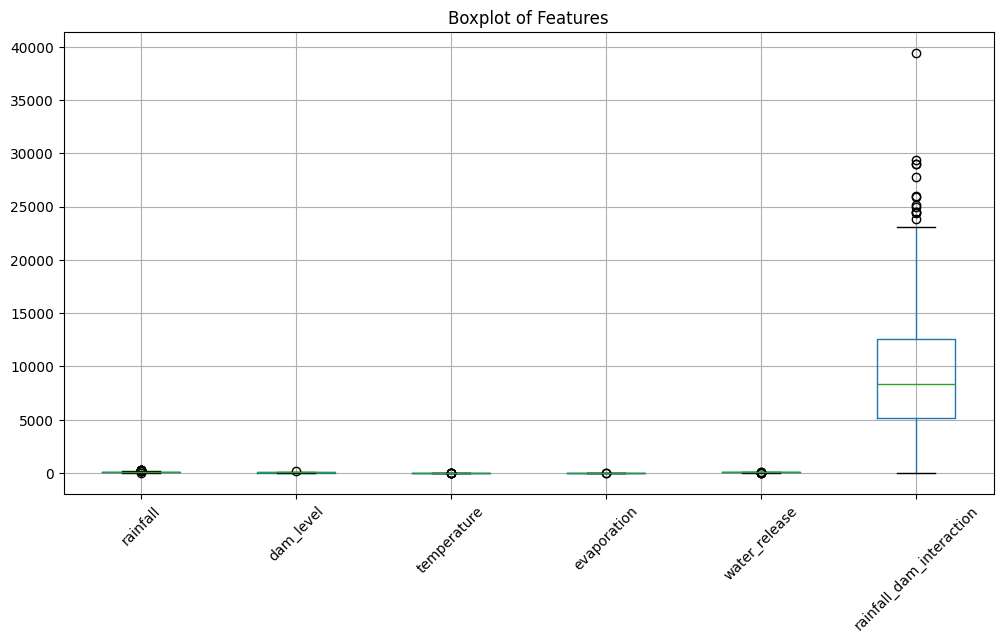

In [ ]:
plt.figure(figsize=(12, 6))
df.drop(columns=[target]).boxplot(rot=45)
plt.title("Boxplot of Features")
plt.show()


## 22) نمودار Actual vs Predicted

در این مرحله مقدار واقعی و مقدار پیش‌بینی‌شده را برای یکی از Foldها با هم مقایسه می‌کنیم.

اگر مدل خوب عمل کرده باشد، نقاط باید به خط قطری نزدیک باشند.


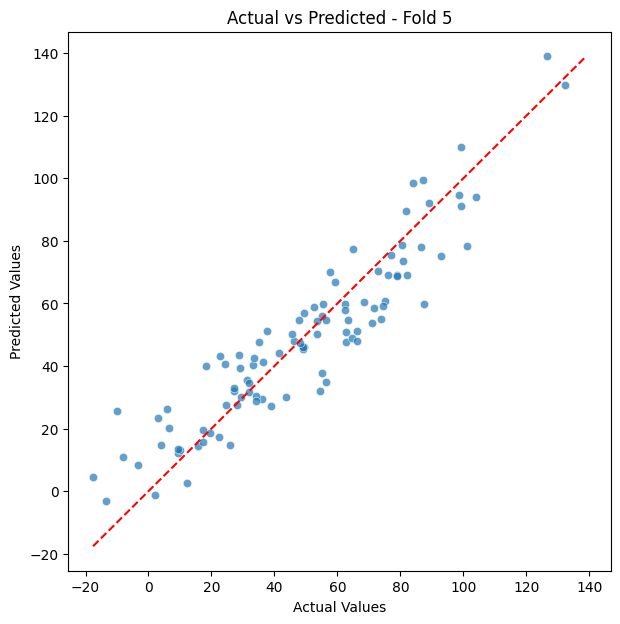

In [ ]:
for fold_num, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    fold_model = LinearRegression()
    fold_model.fit(X_train, y_train)
    y_pred = fold_model.predict(X_test)

    if fold_num == 5:
        plt.figure(figsize=(7, 7))
        sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
        plt.xlabel("Actual Values")
        plt.ylabel("Predicted Values")
        plt.title(f"Actual vs Predicted - Fold {fold_num}")
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], "r--")
        plt.show()
        break


## 23) جمع‌بندی مفهومی

در این نوت‌بوک چند نکته مهم را به‌صورت عملی مشاهده کردیم:

### 1) همبستگی با علیت یکسان نیست
ممکن است دو متغیر با هم همبستگی بالایی داشته باشند، اما یکی علت دیگری نباشد.

### 2) همبستگی فقط رابطه خطی را اندازه می‌گیرد
اگر رابطه غیرخطی باشد، ممکن است ضریب همبستگی تصویر کاملی از ارتباط ارائه ندهد.

### 3) ارزیابی روی کل داده خوش‌بینانه است
چون مدل همان داده‌هایی را می‌بیند که روی آن‌ها ارزیابی می‌شود.

### 4) K-Fold ارزیابی قابل‌اعتماد‌تری می‌دهد
چون مدل روی چند بخش مختلف داده بررسی می‌شود.

### 5) Fold ضعیف باید تحلیل شود
اگر عملکرد یک Fold پایین بود، باید داده‌های همان Fold را جداگانه بررسی کنیم.

### 6) Outlierها مهم‌اند
گاهی داده پرت خطاست و گاهی اطلاعات مهمی دارد؛ بنابراین نباید بدون تحلیل حذف شود.


In [ ]:
print("نکات مهم:")
print("1) همبستگی بالا لزوماً به معنی رابطه علت و معلولی نیست.")
print("2) KFold با shuffle=False باعث می‌شود ایندکس فولدها قابل رهگیری باشند.")
print("3) اگر یک fold ضعیف بود، اول داده‌های آن را با iloc بررسی کن.")
print("4) مهندسی ویژگی باید منطقی باشد، نه صرفاً برای بالا بردن مصنوعی دقت.")
print("5) وجود outlier می‌تواند روی correlation و performance مدل اثر بگذارد.")


نکات مهم:
1) همبستگی بالا لزوماً به معنی رابطه علت و معلولی نیست.
2) KFold با shuffle=False باعث می‌شود ایندکس فولدها قابل رهگیری باشند.
3) اگر یک fold ضعیف بود، اول داده‌های آن را با iloc بررسی کن.
4) مهندسی ویژگی باید منطقی باشد، نه صرفاً برای بالا بردن مصنوعی دقت.
5) وجود outlier می‌تواند روی correlation و performance مدل اثر بگذارد.


# نتیجه نهایی پروژه

در این پروژه توانستیم:

- فایل CSV را در Google Colab آپلود و بارگذاری کنیم
- داده‌ها را از نظر ساختار و کیفیت اولیه بررسی کنیم
- ماتریس همبستگی را محاسبه کنیم
- Heatmap رسم کنیم
- رابطه ویژگی‌ها با متغیر هدف را تحلیل کنیم
- ضریب پیرسون را دستی محاسبه کنیم
- یک ویژگی جدید بسازیم
- مدل رگرسیون خطی آموزش دهیم
- با K-Fold Cross Validation مدل را ارزیابی کنیم
- ضعیف‌ترین Fold را شناسایی و تحلیل کنیم
- داده‌های پرت را بررسی کنیم
- نمودار Actual vs Predicted رسم کنیم

این نوت‌بوک یک تمرین کامل و آموزشی برای مبحث Correlation و Cross Validation است.
